In [66]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import yfinance as yf
import backtrader as bt
sys.path.insert(0, "/home/wborrelli/ex_projects/stochastic_finance/")
from mcpt.donchian import *
from mcpt.trendline_automation import *

# Donchian Breakout

In [12]:
data = yf.download('MSFT', start='2023-01-01', end='2023-10-01')
data = data.iloc[:,0:-1]
data.columns = ['open','high','low','close']

[*********************100%***********************]  1 of 1 completed


In [4]:
fig = go.Figure(data=go.Ohlc(x=data.index,
                             open=data.open,
                             high=data.high,
                             low=data.low,
                             close=data.close))
fig.show()

In [13]:
best_lookback, best_real_pf = optimize_donchian(data)

/home/wborrelli/ex_projects/stochastic_finance/mcpt/donchian.py:23: RuntimeWarning: invalid value encountered in scalar divide
  sig_pf = sig_rets[sig_rets > 0].sum() / sig_rets[sig_rets < 0].abs().sum()


In [19]:
[best_lookback, best_real_pf]

[35, np.float64(1.279289537637574)]

In [14]:
signal = donchian_breakout(data, best_lookback)

data['r'] = np.log(data['close']).diff().shift(-1)
data['donch_r'] = data['r'] * signal

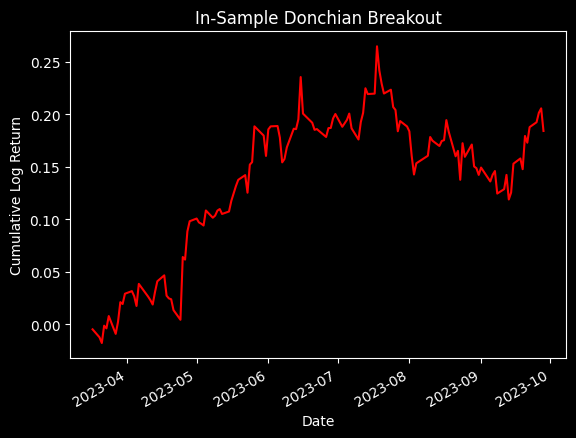

In [18]:
data['donch_r'].cumsum().plot(color='red')
plt.title("In-Sample Donchian Breakout")
plt.ylabel('Cumulative Log Return')
plt.show()

# SMA Support and Resistance

In [59]:
data = yf.download('MSFT', start='2022-01-01', end='2023-01-01')
data = data.iloc[:,0:-1]
data.columns = ['open','high','low','close']

[*********************100%***********************]  1 of 1 completed


In [60]:
data['sma_20'] = data.close.rolling(20).mean()

prev_close = data["close"].shift(1)
tr1 = data["high"] - data["low"]
tr2 = (data["high"] - prev_close).abs()
tr3 = (data["low"] - prev_close).abs()

data["tr"] = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)

# ATR
data["atr_20"] = data["tr"].rolling(20).mean()

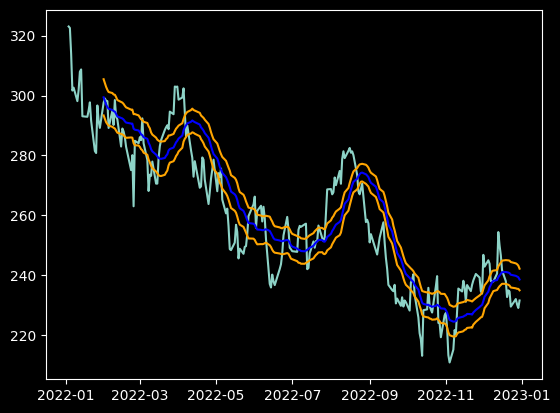

In [64]:
plt.plot(data.index,data.close)
plt.plot(data.index, data.sma_20, c='b')
plt.plot(data.index, data.sma_20 + 0.5*data.atr_20.values, c='orange')
plt.plot(data.index, data.sma_20 - 0.5*data.atr_20.values, c='orange')

# Automated Trendline

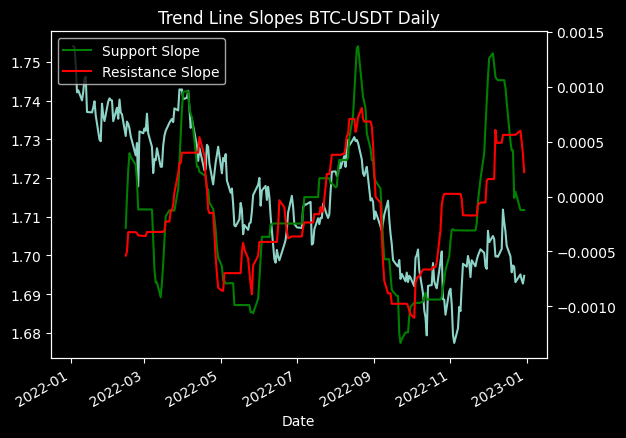

In [74]:
data = np.log(data)
# Trendline parameter
lookback = 30


support_slope = [np.nan] * len(data)
resist_slope = [np.nan] * len(data)
for i in range(lookback - 1, len(data)):
    candles = data.iloc[i - lookback + 1: i + 1]
    support_coefs, resist_coefs =  fit_trendlines_high_low(candles['high'].values, 
                                                           candles['low'].values, 
                                                           candles['close'].values)
    support_slope[i] = support_coefs[0]
    resist_slope[i] = resist_coefs[0]

data['support_slope'] = support_slope
data['resist_slope'] = resist_slope

plt.style.use('dark_background')
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
data['close'].plot(ax=ax1)
data['support_slope'].plot(ax=ax2, label='Support Slope', color='green')
data['resist_slope'].plot(ax=ax2, label='Resistance Slope', color='red')
plt.title("Trend Line Slopes BTC-USDT Daily")
plt.legend()
plt.show()